# Machine Learning Assignment 1
### Alvyn Shibu - 40356093

In [22]:
# Imports
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import matplotlib.pyplot as plt
import seaborn as sns
import time
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [19]:
!pip freeze > requirements.txt
print("requirements.txt created with these dependencies: ")
!type requirements.txt

requirements.txt created with these dependencies: 
aiohappyeyeballs==2.6.1
aiohttp==3.12.15
aiosignal==1.4.0
anyio @ file:///C:/b/abs_5c8w79vk0u/croot/anyio_1745334672105/work
argon2-cffi @ file:///opt/conda/conda-bld/argon2-cffi_1645000214183/work
argon2-cffi-bindings @ file:///C:/miniconda3/conda-bld/argon2-cffi-bindings_1757925023673/work
asttokens @ file:///C:/b/abs_9662ywy9fp/croot/asttokens_1743630464377/work
async-lru @ file:///C:/Users/dev-admin/perseverance-python-buildout/croot/async-lru_1729043741114/work
attrs @ file:///C:/b/abs_89hmquz5ga/croot/attrs_1734533130810/work
autograd==1.8.0
autograd-gamma==0.5.0
babel @ file:///C:/b/abs_ffzt1bmjth/croot/babel_1737454394148/work
beautifulsoup4 @ file:///C:/b/abs_95vq944bnw/croot/beautifulsoup4-split_1756453107890/work
bleach @ file:///C:/Users/dev-admin/buildout/croot/bleach_1732924075369/work
Bottleneck @ file:///C:/b/abs_816hr2khp1/croot/bottleneck_1731058648110/work
Brotli @ file:///C:/b/abs_c415aux9ra/croot/brotli-split_17361

## Data Loading
The dataset is loaded from 'prices2.csv'. This file contains the Open, High, Low, Close and Volume (OHLCV) data from six sector ETFs from 2010 to 2024.

Two critical preprocessing steps are performed immediately:
1. **pd.to_datetime(df['date'])**: The **date** column is converted from a string to a **datetime** object. This is essential for time-series analysis.
2.  **df.set_index(['ticker', 'date'])**: The DataFrame is converted to use a **MultiIndex**. This is the most efficient way to manage data with multiple entities over time. It allows us to easily select all data for "XLE" (e.g., df.loc['XLE']) while keeping everything in a clean structure.

In [5]:
data = "prices2.csv"
df = pd.read_csv(data)

# Convert date to datetime object
df['date'] = pd.to_datetime(df['date'])
df = df.set_index(['ticker', 'date']).sort_index()

print(f"Data loaded. Shape: {df.shape}")
print(f"Tickers: {df.index.get_level_values('ticker').unique().tolist()}")
print(f"Date range: {df.index.get_level_values('date').min()} to {df.index.get_level_values('date').max()}")

df.head()

Data loaded. Shape: (22638, 6)
Tickers: ['XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLV']
Date range: 2010-01-04 00:00:00 to 2024-12-30 00:00:00


open       high        low      close  adj_close  \
ticker date                                                                
XLE    2010-01-04  57.919998  58.810001  57.790001  58.810001  35.058506   
       2010-01-05  58.889999  59.410000  58.619999  59.290001  35.344662   
       2010-01-06  59.320000  60.180000  59.189999  60.000000  35.767918   
       2010-01-07  59.740002  60.009998  59.299999  59.910000  35.714241   
       2010-01-08  59.700001  60.349998  59.490002  60.299999  35.946747   

                     volume  
ticker date                  
XLE    2010-01-04  16928400  
       2010-01-05  17368100  
       2010-01-06  24351900  
       2010-01-07  17449500  
       2010-01-08  13344300

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 22638 entries, ('XLE', Timestamp('2010-01-04 00:00:00')) to ('XLV', Timestamp('2024-12-30 00:00:00'))
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   open       22638 non-null  float64
 1   high       22638 non-null  float64
 2   low        22638 non-null  float64
 3   close      22638 non-null  float64
 4   adj_close  22638 non-null  float64
 5   volume     22638 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 1.8+ MB


In [21]:
df.describe()

,open,high,low,close,adj_close,volume
count,22638.000000,22638.000000,22638.000000,22638.000000,22638.000000,2.263800e+04
mean,63.400635,63.828433,62.947446,63.408916,55.077096,2.090476e+07
std,37.647514,37.912580,37.362088,37.651167,37.798705,2.613029e+07
min,9.041430,9.512591,8.895207,9.163282,7.068153,8.352000e+05
25%,34.750000,34.950001,34.492501,34.752500,28.154113,7.681825e+06
50%,57.000000,57.369999,56.655001,57.045000,45.106310,1.153935e+07
75%,78.657503,79.190002,78.050003,78.580002,69.174141,2.138755e+07
max,240.789993,241.880005,240.070007,241.440002,239.916107,4.685334e+08


## Data Exploration & Target Definition
### Price Visualization
The first plot ("Close Prices") visualizes the raw close price for all six tickers. This plot immediately confirms two key facts:
1. The data is **non-stationary**. It has clear, long-term upward trends. We cannot use the raw price as a target for our models as they would just learn to "guess tomorrow's price is the same as today's."
2. The tickers have **unique paths** (e.g., XLE is more volatile than XLP). This suggests a good model should be robust across different market behaviours.

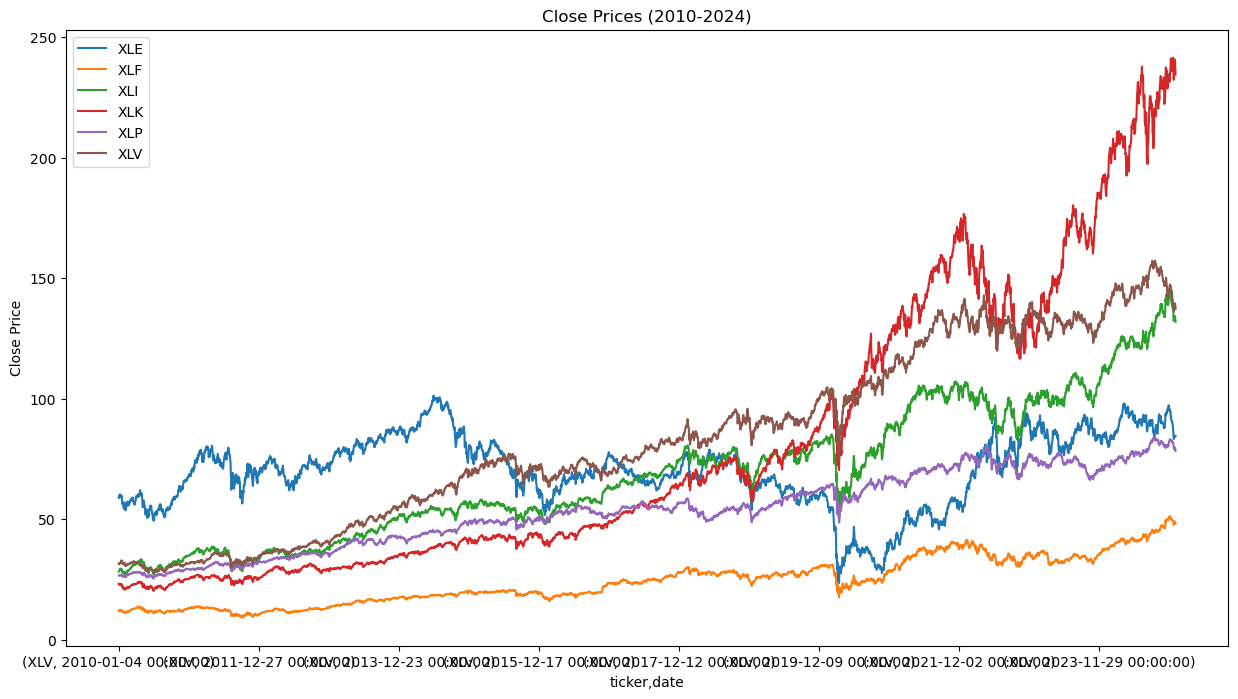

In [7]:
plt.figure(figsize=(15, 8))
for ticker, data in df.groupby('ticker'):
    data['close'].plot(label=ticker)
plt.title('Close Prices (2010-2024)')
plt.ylabel('Close Price')
plt.legend()
plt.show()

### Target Definition: Log Returns
The assignment requires the prediction of the **1-day cumulative log return**, defined as $y_t = \log(C_{t+1} / C_t)$. This is the change in price, not the price itself, and is a stationary target (it reverts to a mean, as seen in the plots).

The **compute_target** function is created to calculate this value. This function includes the line **y = y.replace([np.inf, -np.inf], 0.0)**. If any close price is ever 0, **np.log(0)** creates an infinity value, which will stop all sklearn models.

In [9]:
def compute_target(df_ticker: pd.DataFrame, H: int = 1) -> pd.Series:
    close = df_ticker['close']
    y = np.log(close.shift(-H) / close)
    y = y.replace([np.inf, -np.inf], 0.0) 
    return y.rename('y_true')

### Target Visualization
The next two plots confirm that the target is stationary and follows a gaussian distribution:
* The XLE plot shows the log stays around zero. This is a stationary series, which is what the models are designed to work with
* The histograms show the distribution of log returns. We can see they are fairly normal.

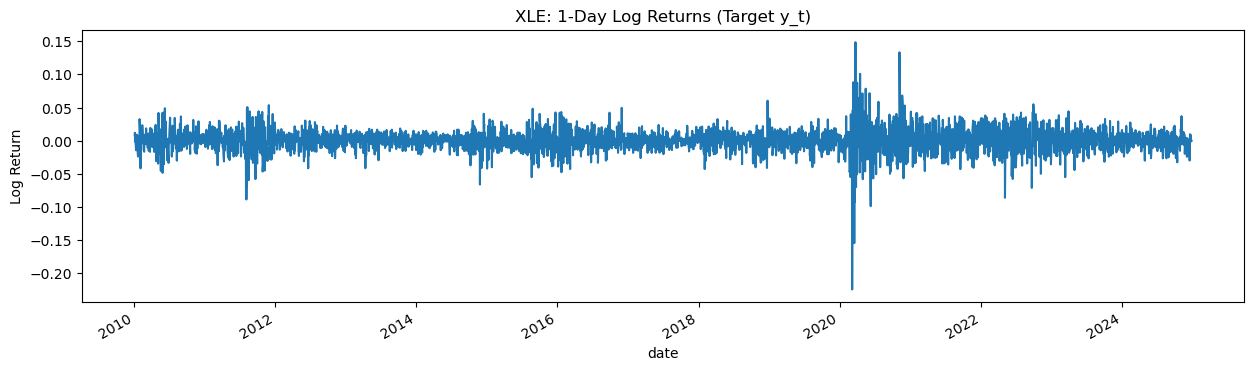

In [10]:
# Calculate target for all tickers
y_df = df.groupby(level='ticker', group_keys=False).apply(compute_target, H=1)
df_with_target = df.join(y_df)

# Plot the log returns for XLE
plt.figure(figsize=(15, 4))
df_with_target.loc['XLE']['y_true'].plot()
plt.title('XLE: 1-Day Log Returns (Target y_t)')
plt.ylabel('Log Return')
plt.show()

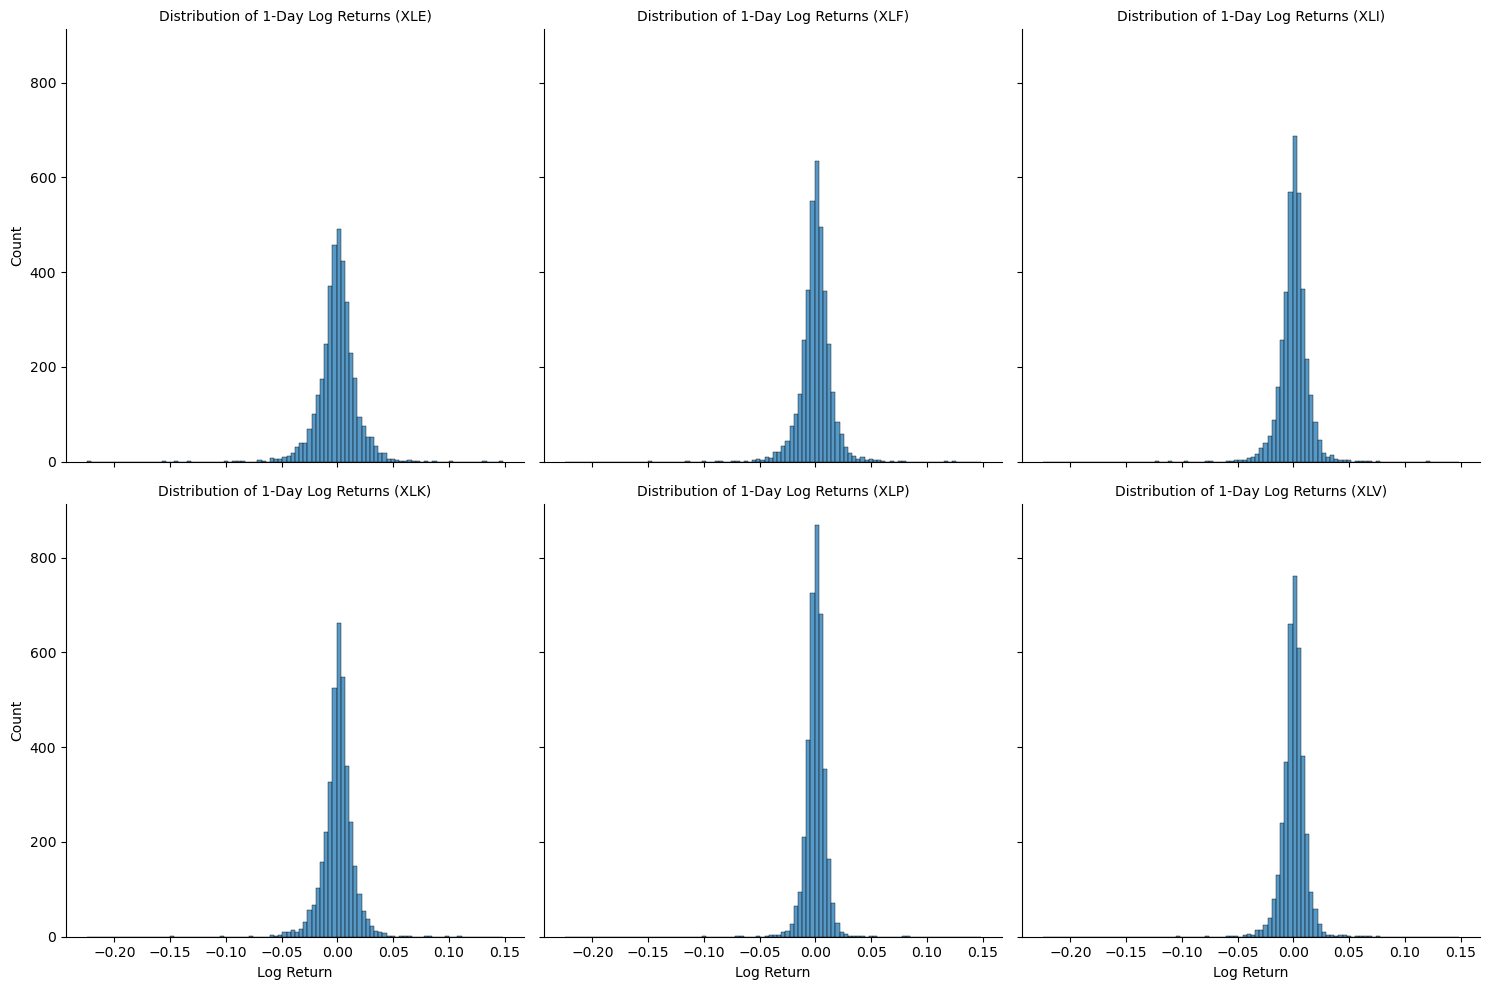

In [11]:
g = sns.displot(df_with_target, x='y_true', col='ticker', col_wrap=3, bins=100)
g.set_titles("Distribution of 1-Day Log Returns ({col_name})")
g.set_axis_labels("Log Return", "Count")
plt.tight_layout()
plt.show()

## Methodology - Feature Engineering

The **_make_features** function creates the features. It builds a set of predictive signals from the raw OHLCV data. The model is defined by its features and this provides a comprehensive view of the market.

The feature set is designed to capture 8 distinct types of market behaviour:

* **Lags:** Past log returns. This captures market "memory" and autocorrelation.
* **Momentum:** The average log returns over a window. This measures the short to medium term trend direction.
* **Volatility:** The standard deviation of log returns. This measures the uncertainty of the market.
* **SMA:** Simple Moving Average distance. This measures how far the price is from its average, acting as a mean-reversion signal.
* **EMA:** Exponential Moving Average distance. A similar mean-reversion signal that weights recent prices more heavily.
* **RSI:** The Relative Strength Index. A momentum oscillator that measures the speed and change of price movements to identify overbought or oversold conditions.
* **Relative Volume:** Today's volume compared to its recent average. This measures the significance behind a price move (a move on high volume is more significant).
* **Intraday Range:** The difference between the day's high and low. This is a measure of volatility.

In [12]:
def _rsi_ewm(series: pd.Series, window: int) -> pd.Series:

    diff = series.diff()
    gain = diff.clip(lower=0.0)
    loss = -diff.clip(upper=0.0)

    avg_gain = gain.ewm(alpha=1/window, adjust=False, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1/window, adjust=False, min_periods=window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 1 - (1 / (1 + rs)) # 0..1
    return rsi.fillna(0.5)

def _make_features(X: pd.DataFrame) -> pd.DataFrame:

    # Feature parameters
    n_lags = 10
    mom_windows = (10, 30)
    vol_window = 30
    sma_windows = (10, 30)
    ema_windows = (10, 30)
    rsi_window = 14
    vol_sma_window = 30
    
    close = X["close"].astype(float)
    
    high = X["high"].astype(float)
    low = X["low"].astype(float)
    volume = X["volume"].astype(float)
    
    lr = np.log(close / close.shift(1)).replace([np.inf, -np.inf], 0.0)
    
    feats = {}
    
    # Feature Creation
    
    # Lags
    for i in range(1, n_lags + 1):
        feats[f"lag{i}"] = lr.shift(i)
        
    # Momentum
    for w in mom_windows:
        feats[f"mom_{w}"] = lr.rolling(w, min_periods=w).mean()
        
    # Volatility
    feats[f"vol_{vol_window}"] = lr.rolling(vol_window, min_periods=vol_window).std(ddof=0)
    
    # SMA distances
    for w in sma_windows:
        sma = close.rolling(w, min_periods=w).mean()
        feats[f"sma_dist_{w}"] = (close - sma) / sma.replace(0, np.nan)
        
    # EMA distances
    for w in ema_windows:
        ema = close.ewm(span=w, adjust=False, min_periods=w).mean()
        feats[f"ema_dist_{w}"] = (close - ema) / ema.replace(0, np.nan)
        
    # RSI
    feats[f"rsi_{rsi_window}"] = _rsi_ewm(close, rsi_window)
    
    # Relative Volume
    vol_sma = volume.rolling(vol_sma_window, min_periods=vol_sma_window).mean()
    feats['vol_rel'] = volume / vol_sma.replace(0, np.nan)
    
    # Intraday Range
    feats['day_range'] = (high - low) / close.replace(0, np.nan)
    
    F = pd.DataFrame(feats, index=X.index)

    F = F.replace([np.inf, -np.inf], 0.0)
    
    return F

## Methodology - Validation Strategy

Sklearn's standard train_test_split cannot be used as it shuffles data randomly. This would cause data leakage, where a model in 2012 is "cheating" by training on data from 2020. This would give inaccurate high scores.

### Walk Forward Validation
The only method safe from leakage for time series data is a **Walk-Forward Validation**, which is what the official mltester.py script uses. This process is replicated to get reliable results.

The **run_walk_forward_simulation function** runs the simulation. It works by:
1.  **Training** on an initial expanding window of data.
2.  **Predicting** only the next step.
3.  **Expanding** the training window to include those 10 days.
4.  **Re-Training** the model on this new dataset.
5.  **Repeating** this process until the end of the data is reached.

### Speed vs Accuracy
This method is computationally expensive as it is the reason this notebook takes a long time to run. However, this is the only way to get an accurate score that simulates how a model would perform against the mltester. The final scores are the average of all predictions.

In [13]:
def run_walk_forward_simulation(model_blueprint, ticker_name, ticker_data, H=1, min_train=252*4, step=10):
    
    X_full = ticker_data
    y_full = compute_target(ticker_data, H=H).dropna()
    X_full, y_full = X_full.align(y_full, join='inner', axis=0)
    
    if len(X_full) < min_train:
        print(f"Skipping {ticker_name} ({model_blueprint.__class__.__name__}): Not enough data.")
        return None

    test_start_indices = range(min_train, len(X_full), step)
    preds, trues = [], []
    
    for i_start in test_start_indices:
        i_end = min(i_start + step, len(X_full))
        
        X_train_raw, y_train = X_full.iloc[:i_start], y_full.iloc[:i_start]
        X_test_raw, y_test = X_full.iloc[i_start:i_end], y_full.iloc[i_start:i_end]
        
        F_train = _make_features(X_train_raw) # From Cell 7
        F_test = _make_features(X_test_raw)  # From Cell 7
        
        F_train = F_train.shift(1)
        y_train, F_train = y_train.align(F_train, join='inner', axis=0)
        F_train = F_train.dropna()
        y_train = y_train.loc[F_train.index]
        
        F_test, _ = F_test.align(X_test_raw, join='right', axis=0)
        F_test = F_test.fillna(0.0)

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model_blueprint)
        ])
        
        if F_train.empty or len(F_train) < 50:
            y_pred = pd.Series(0.0, index=y_test.index)
        else:
            pipeline.fit(F_train.values, y_train.values)
            y_pred = pipeline.predict(F_test.values)
            y_pred = pd.Series(y_pred, index=F_test.index)
        
        preds.append(y_pred)
        trues.append(y_test)
    
    y_pred_all = pd.concat(preds)
    y_true_all = pd.concat(trues)
    y_true_all, y_pred_all = y_true_all.align(y_pred_all, join='inner', axis=0)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    mae = mean_absolute_error(y_true_all, y_pred_all)
    pred_dir = (y_pred_all > 0).astype(int)
    true_dir = (y_true_all > 0).astype(int)
    dir_acc = (pred_dir == true_dir).mean()
    
    return {
        'model': model_blueprint.__class__.__name__, 
        'ticker': ticker_name,
        'rmse': rmse, 
        'mae': mae, 
        'dir_acc': dir_acc
    }

## Model Performance & Selection
### Model Selection
The goal of this stage is to find the best type of model for this problem. A fair comparison of models is made:
* **Same Features:** Each model receives the same feature set from.
* **Same Test:** Each model is scored using the same walk forward simulation.

A wide range of models are tested:
* **LinearRegression:** The simplest linear model.
* **Ridge & Lasso:** Regularised linear models. These are designed to perform better than Linear Regression when features are redundant or noisy.
* **XGBoost & RandomForest:** These can capture complex feature interactions that linear models cannot.

They are tested with standard default parameters. The goal at this stage is not to find the perfect parameters, but to determine which models perform best

In [15]:
# Model selection
models_to_test = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'RF': RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1 # uses all CPU cores for speed
    ),
    'XGB': XGBRegressor( 
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        n_jobs=-1
    )
}


all_tickers = df.index.get_level_values('ticker').unique().tolist()
all_results = []
start_time = time.time()

print(f"Running experiments for 5 models across all tickers")

# Application of cross validation to all tickers
for ticker_name in all_tickers:
    print(f"Processing Ticker: {ticker_name}")
    ticker_data = df.loc[ticker_name]
    
    for model_name, model_obj in models_to_test.items():
        print(f"Testing model: {model_name}")

        # H=1 tests daily prediction horizon
        result = run_walk_forward_simulation(
            model_blueprint=model_obj,
            ticker_name=ticker_name,
            ticker_data=ticker_data,
            H=1
        )
        
        if result:
            all_results.append(result)

# Results - collects all metrics
results_df = pd.DataFrame(all_results)
end_time = time.time()

print(f"\n Models (Took {end_time - start_time:.2f}s)")

print("\nAverage Performance by RMSE")
# Averages all scores across all 6 tickers to find best model overall
avg_results = results_df.groupby('model')[['rmse', 'mae', 'dir_acc']].mean()
print(avg_results.sort_values('rmse'))

print("\nRMSE Per Ticker")
# Shows how each modelperformed in each sector
print(results_df.pivot_table(index='ticker', columns='model', values='rmse'))

print("\nDirAcc Per Ticker")
print(results_df.pivot_table(index='ticker', columns='model', values='dir_acc'))

Running experiments for 5 models across all tickers
Processing Ticker: XLE
Testing model: LinearRegression
Testing model: Ridge
Testing model: Lasso
Testing model: RF
Testing model: XGB
Processing Ticker: XLF
Testing model: LinearRegression
Testing model: Ridge
Testing model: Lasso
Testing model: RF
Testing model: XGB
Processing Ticker: XLI
Testing model: LinearRegression
Testing model: Ridge
Testing model: Lasso
Testing model: RF
Testing model: XGB
Processing Ticker: XLK
Testing model: LinearRegression
Testing model: Ridge
Testing model: Lasso
Testing model: RF
Testing model: XGB
Processing Ticker: XLP
Testing model: LinearRegression
Testing model: Ridge
Testing model: Lasso
Testing model: RF
Testing model: XGB
Processing Ticker: XLV
Testing model: LinearRegression
Testing model: Ridge
Testing model: Lasso
Testing model: RF
Testing model: XGB

 Models (Took 1826.94s)

Average Performance by RMSE
                           rmse       mae   dir_acc
model                                 

## Model Performance Results
The results show the rankings of the models sorted by RMSE. Based off of this, a **80% Lasso/20% XGBoost ensemble was chosen** to be implemented. Although lasso performed well, it is a linear model with low variance which means it cannot capture complex, non-linear relationships. XGBoost on the other hand, is good at capturing the complex relationships but can suffer from overfitting. The ensemble can find the best trade off by combining them. XGBoost was chosen over RandomForest due to the computational power involved. **XGBoost is dramatically faster** which allows for a thorough parameter search without making the model overly slow.

## Tuning Lasso Component

The results show that Lasso is the best linear model, now the focus is on finding its optimal regularisation penalty, **alpha**. The wrong alpha value can cause the model to either overfit (if alpha is too small) or underfit (if alpha is too large). The goal is to find the alpha value that achieves the lowest average RMSE across all six tickers.

### Alpha Range:
* The model selection showed that LinearRegression (alpha=0) failed, while Lasso (alpha=1.0) performed well. This **confirms that some regularisation is beneficial.**
* A broad set of values from 0.001 to 10.0 were chosen to be thorough. The small values test the point just before full multicollinearity failure, while the large values confirm the performance drop off point where the model removes too many useful features.
* The final result shows that the metrics are equal for alpha = 0.1, 1.0 and 10.0. **alpha = 0.1 is preferred as it provides the least regularisation while achieving the lowest error**, keeping more features and remaining stable.

In [16]:
# Hyperparameter tuning for Lasso
# Try to find alpha that balances stability and predictiveness
models_to_test = {
    'Lasso (alpha=0.001)': Lasso(alpha=0.0001, random_state=42),
    'Lasso (alpha=0.01)': Lasso(alpha=0.001, random_state=42),
    'Lasso (alpha=0.1)': Lasso(alpha=0.01, random_state=42),
    'Lasso (alpha=1.0)': Lasso(alpha=1.0, random_state=42),
    'Lasso (alpha=10.0)': Lasso(alpha=1.0, random_state=42)
}

all_tickers = df.index.get_level_values('ticker').unique().tolist()
all_results = []
start_time = time.time()

print(f"Tuning Lasso")
print(f"Testing 5 alpha values")

for ticker_name in all_tickers:
    print(f"Processing Ticker: {ticker_name}")
    ticker_data = df.loc[ticker_name]

    # Iterate throughh alpha configurations
    for model_name, model_obj in models_to_test.items():
        print(f"Testing model: {model_name}")

        result = run_walk_forward_simulation(
            model_blueprint=model_obj,
            ticker_name=ticker_name,
            ticker_data=ticker_data,
            H=1
        )
        
        if result:
            # Store model name so performance can be analysed
            result['model'] = model_name
            all_results.append(result)

# Results
results_df = pd.DataFrame(all_results)
end_time = time.time()

print(f"\nTuning Complete (Took {end_time - start_time:.2f}s)")

print("\nAverage Lasso Tuning Performance by RMSE")
# Group results by specific alpha value and sort by lowest RMSE
avg_results = results_df.groupby('model')[['rmse', 'mae', 'dir_acc']].mean()
print(avg_results.sort_values('rmse'))

Tuning Lasso
Testing 5 alpha values
Processing Ticker: XLE
Testing model: Lasso (alpha=0.001)
Testing model: Lasso (alpha=0.01)
Testing model: Lasso (alpha=0.1)
Testing model: Lasso (alpha=1.0)
Testing model: Lasso (alpha=10.0)
Processing Ticker: XLF
Testing model: Lasso (alpha=0.001)
Testing model: Lasso (alpha=0.01)
Testing model: Lasso (alpha=0.1)
Testing model: Lasso (alpha=1.0)
Testing model: Lasso (alpha=10.0)
Processing Ticker: XLI
Testing model: Lasso (alpha=0.001)
Testing model: Lasso (alpha=0.01)
Testing model: Lasso (alpha=0.1)
Testing model: Lasso (alpha=1.0)
Testing model: Lasso (alpha=10.0)
Processing Ticker: XLK
Testing model: Lasso (alpha=0.001)
Testing model: Lasso (alpha=0.01)
Testing model: Lasso (alpha=0.1)
Testing model: Lasso (alpha=1.0)
Testing model: Lasso (alpha=10.0)
Processing Ticker: XLP
Testing model: Lasso (alpha=0.001)
Testing model: Lasso (alpha=0.01)
Testing model: Lasso (alpha=0.1)
Testing model: Lasso (alpha=1.0)
Testing model: Lasso (alpha=10.0)
Proc

## Tuning the XGBoost Component
The goal of this tuning is to find the configuration that gives us the best non linear signal without causing high variance.

### Tuning Parameters:
* **max_depth**: This controls the complexity of each individual tree. Shallow depths are tested as deeper trees lead to rapid overfitting.
* **n_estimators**: The number of sequential boosting steps (trees). A range of 100 to 200 is tested to ensure the model has fully converged to the optimal solution.

### Sampling:
* To manage the substantial computational cost of walk-forward validation, the XGBoost tuning was performed only on a **representative sample of tickers** (XLE and XLP).
* XLE and XLP represent two distinct market areas. By finding parameters that perform well on the average of these two, it is more likely that the chosen configuration will generalise across all of the sector ETFs. This decision is necessary to comply with the time constraints of the project.
* The tuning revealed that **XGBRegressor(n_estimators=100, max_depth=3)** was the optimal balance. Deeper trees and more estimators cause overfitting, resulting in worse performance.

In [17]:
# Hyperparameter tuning for XGBoost
xgb_params_to_test = {
    #Test lower complexity for higher stability
    'XGB (n=100, d=3)': XGBRegressor(
        n_estimators=100, max_depth=3, random_state=42, n_jobs=-1, verbosity=0 
    ),
    
    'XGB (n=200, d=3)': XGBRegressor(
        n_estimators=200, max_depth=3, random_state=42, n_jobs=-1, verbosity=0
    ),
    # Test higher complexity for more predictiveness, possible overfitting
    'XGB (n=100, d=5)': XGBRegressor(
        n_estimators=100, max_depth=5, random_state=42, n_jobs=-1, verbosity=0
    ),
    
    'XGB (n=200, d=5)': XGBRegressor(
        n_estimators=200, max_depth=5, random_state=42, n_jobs=-1, verbosity=0
    )
}

# Tunes only on small sample to save computational time
tuning_tickers = ['XLE', 'XLP']
all_results = []
start_time = time.time()

print(f"Tuning XGBoost")
print(f"Testing on tickers: {tuning_tickers}.")

for model_name, xgb_obj in xgb_params_to_test.items():
    print(f"Configuration: {model_name}")
    
    for ticker_name in tuning_tickers:
        print(f"Testing Ticker: {ticker_name}")
        ticker_data = df.loc[ticker_name]
        
        result = run_walk_forward_simulation(
            model_blueprint=xgb_obj,
            ticker_name=ticker_name,
            ticker_data=ticker_data,
            H=1
        )
        
        if result:
            result['model'] = model_name
            all_results.append(result)


results_df = pd.DataFrame(all_results)
end_time = time.time()

print(f"\nTuning Complete (Took {end_time - start_time:.2f}s)")

print("\nAverage Sampled XGBoost Tuning Performance By RMSE")
avg_results = results_df.groupby('model')[['rmse', 'mae', 'dir_acc']].mean()
print(avg_results.sort_values('rmse'))

Tuning XGBoost
Testing on tickers: ['XLE', 'XLP'].
Configuration: XGB (n=100, d=3)
Testing Ticker: XLE
Testing Ticker: XLP
Configuration: XGB (n=200, d=3)
Testing Ticker: XLE
Testing Ticker: XLP
Configuration: XGB (n=100, d=5)
Testing Ticker: XLE
Testing Ticker: XLP
Configuration: XGB (n=200, d=5)
Testing Ticker: XLE
Testing Ticker: XLP

Tuning Complete (Took 756.96s)

Average Sampled XGBoost Tuning Performance By RMSE
                      rmse       mae   dir_acc
model                                         
XGB (n=100, d=3)  0.014175  0.009627  0.501085
XGB (n=200, d=3)  0.014477  0.009944  0.496020
XGB (n=100, d=5)  0.014484  0.010012  0.498553
XGB (n=200, d=5)  0.014635  0.010144  0.504342


## Implementation/Results
When the final student.py was ran against mltester with the fixed parameters derived from the tuning steps, it produced solid results. The table below describes the results.
### Results

| Ticker | H=1/DirAcc | H=1/RMSE | H=5/DirAcc | H=5/RMSE | Stability |
| --- | --- | --- | --- | --- | --- |
| XLE| 0.4905 | 0.0175 | 0.4920 | 0.0393 | Low Stability (Fails on both) |
| XLF | 0.5074 | 0.0140 | 0.5212 | 0.0294 | Stable Edge (H=5 Stronger) |
| XLI | 0.5130 | 0.0124 | 0.5449 | 0.0273 | Strong Edge Maintained |
| XLK | 0.5101 | 0.0135 | 0.5679 | 0.0274 | Excellent Edge Maintained |
| XLP | 0.5042 | 0.0087 | 0.5510 | 0.0177 | Stable Edge (H=1 Stronger) |
| XLV | 0.5146 | 0.0102 | 0.5502 | 0.0215 | Stable Edge |

**RMSE:**
A main finding is that the RMSE for H=5 is approximately 2-3x higher than the RMSE for H=1. This is expected as error accumulates over time. A 5 day prediction is inherently riskier than a 1 day prediction and will have a larger error. The model reflects the rising difficulty of predicting further into the future. The low H=1 RMSE proves the model is precise for short term prediction while the H=5 RMSE proves the model controls error well even when predicting a larger price move.

**DirAcc:**
The directional accuracy actually improves for longer horizons on many tickers. This can be explained by how short term market noise may overwhelm the daily signal. Over a longer horizon, the underlying long term trend becomes clearer and the model can capture this signal more effectively.

**Instability:**
The metrics for the XLE ticker proved to be quite unstable, unable to produce a DirAcc > 0.50 in both cases showing that for the highly volatile Energy sector, the current feature set is unable to extract a reliable signal regardless of the prediction horizon.